In [46]:
# Import packages
import numpy as np
import pandas as pd
import hdbscan
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets, linear_model, metrics
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
import statsmodels.api as sm
from functions_fcsuml import *
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Load data
df = pd.read_parquet('Optimal_clustering_260304.parquet')
df.head()


,0,1,2,3,4,5,6,7,8,9,...,155,156,157,158,159,160,161,162,163,164
0,1.0,0.566352,0.872661,0.112121,0.083333,0.010921,0.071429,0.0,0.000000,0.142857,...,0.0,0.0,0.517219,0.458438,0.473857,0.570476,0.350873,0.927632,0.424929,0.939202
1,1.0,0.609360,0.914167,0.055556,0.032051,0.007819,0.267857,0.0,0.000000,0.142857,...,0.0,0.0,0.600048,0.463812,0.473857,0.570476,0.350966,0.955592,0.408947,0.942989
2,1.0,0.530920,0.822566,0.089899,0.104167,0.007205,0.607143,0.0,0.271237,0.428571,...,0.0,0.0,0.510069,0.425069,0.473857,0.570476,0.347950,0.869243,0.331812,0.930188
3,1.0,0.571062,0.914842,0.040404,0.145833,0.004844,0.517857,0.0,0.126677,0.714286,...,0.0,0.0,0.575083,0.464664,0.473857,0.570476,0.348074,0.000000,0.226061,0.000000
4,1.0,0.351149,0.835848,0.036364,0.256410,0.010905,0.625000,0.0,0.000000,0.142857,...,0.0,0.0,0.616053,0.417631,0.473857,0.570476,0.346713,0.839638,0.380631,0.924178


In [3]:
name_list = ['norm_data_260303.parquet', 'norm_targets_260303.parquet', 'norm_testing_targets_260303.parquet', 'norm_validation_targets_260303.parquet',
             'norm_validation_data_260303.parquet', 'norm_testing_data_260303.parquet']
data_list = []

for i in range(len(name_list)):
    temp = pd.read_parquet(name_list[i])
    data_list.append((temp.to_numpy()))

norm_data, norm_targets, norm_testing_targets, norm_validation_targets, norm_validation_data, norm_testing_data = data_list

[    0.     0.  3242.  6188. 12929. 22047. 40621. 56473. 59507. 73304.]
avg sil: -0.007331759698183008 
 cluster silhouettes: 
 [[ 1.          0.20631037]
 [ 2.          0.16858509]
 [ 3.          0.04643743]
 [ 4.         -0.01988519]
 [ 5.         -0.05491842]
 [ 6.         -0.05735584]
 [ 7.          0.17478066]
 [ 8.         -0.03157959]] 
 argmax 0


/Users/davidbaaw/code/Exjobb/functions_fcsuml.py:95: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1, y1, c = cmap(i), s = 1)


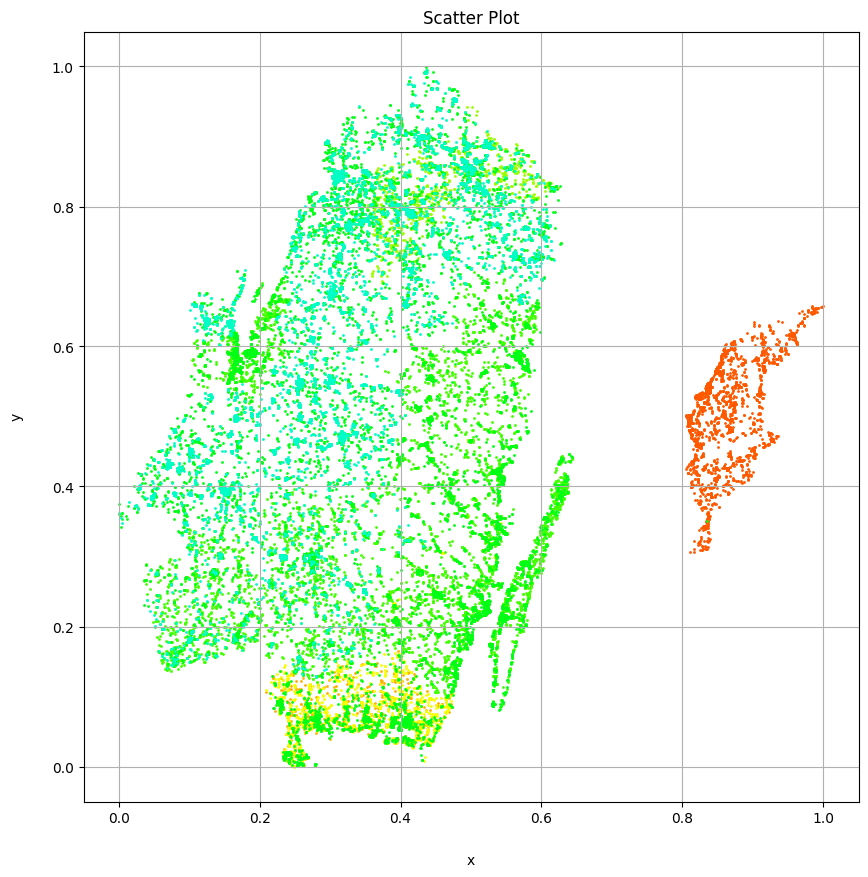

In [4]:
optimal_clustering = pd.DataFrame.to_numpy(df)

sorted_clusters = optimal_clustering[optimal_clustering[:, 0].argsort()] # sorting the clustered data by cluster affiliation
number_of_clusters = int(np.max(sorted_clusters[:,0]))
clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)
print(clusterspan)
average_silhouette, cluster_silhouettes = silhouette(sorted_clusters, number_of_clusters)
print('avg sil:', average_silhouette, '\n cluster silhouettes: \n', cluster_silhouettes, '\n argmax', np.argmax(cluster_silhouettes[:,1]))
show_clusters_in_latlon(norm_data, sorted_clusters, number_of_clusters, clusterspan,2, 1)

In [5]:
def center_of_mass(number_of_clusters, clusters):
    """Takes a number of clusters and a matrix with points declaring where the first column references which cluster to which the point belongs and
    the rest the coordinates of the point."""
    cluster_centers = np.zeros((number_of_clusters, len(clusters[0])))
    balancing_vector = np.zeros_like(cluster_centers)
    clusters[:,0] += 1
    for i in range(len(clusters[:,None])):
        if clusters[i,0] > 0:
            cluster_centers[int(clusters[i,0])-1] += clusters[i]
            balancing_vector[int(clusters[i,0])-1] += 1 # Keeps track of how many points are in each cluster.
    return cluster_centers / balancing_vector

def center_of_mass(number_of_clusters, clusters):

    cluster_centers = np.zeros((number_of_clusters, np.shape(clusters)[1]))
    # print(cluster_centers.shape)
    # print(clusters[np.where(clusters[:,0] == 1)])
    # balancing_vector = np.zeros_like
    for i in range(1, number_of_clusters+1):
        cluster_x = clusters[np.where(clusters[:,0] == i)]
        # print(np.shape(cluster_x))
        cluster_centers[i-1,:] = np.sum(cluster_x, axis=0) / np.shape(cluster_x)[0]

    return cluster_centers


def vector_norm(vector):
    return np.sqrt(vector @ vector.T)

def create_unit_vector(vector):
    """Takes a vector and creates a unit vector in the same direction."""
    unit_vector = vector / vector_norm(vector)
    return unit_vector

def create_basis(centers_of_mass):
    """Takes the centers_of_mass array and outputs a transformation matrix."""
    basis = np.zeros_like(centers_of_mass[:, 1:])
    for i in range(len(centers_of_mass[:, None])):
        basis[i] = create_unit_vector(centers_of_mass[i, 1:])

    return basis

centers_of_mass = center_of_mass(number_of_clusters, sorted_clusters)
print(centers_of_mass)
transformation_matrix = create_basis(centers_of_mass)

"""
print(np.shape(transformation_matrix@norm_data.T))
print(centers_of_mass)
print(transformation_matrix)
print(transformation_matrix[1,:]@transformation_matrix[1,:].T)
print(transformation_matrix@norm_data.T)
"""

embedded_data = (transformation_matrix@norm_data.T).T

# norm_embedded_data = normalize(embedded_data)

# print(embedded_data)
print(np.shape(embedded_data))
# print(norm_embedded_data)

[[1.         0.51028853 0.85930189 ... 0.67048012 0.36226425 0.70292064]
 [2.         0.06789781 0.32805411 ... 0.54425855 0.33117418 0.59464579]
 [3.         0.14551028 0.38090748 ... 0.77250869 0.38114994 0.79914716]
 ...
 [6.         0.5068559  0.36209759 ... 0.30870363 0.28627405 0.32326062]
 [7.         0.80227259 0.34534289 ... 0.77201882 0.36994085 0.81052844]
 [8.         0.58278603 0.28196519 ... 0.58135845 0.33548206 0.6073243 ]]
(73304, 8)


In [6]:

model = LinearRegression()

embedded_testing_data = (transformation_matrix@norm_testing_data.T).T

model.fit(embedded_data, norm_targets)
prediction = model.predict(embedded_testing_data)

print(prediction, norm_testing_targets, 'diff:', np.mean(abs(prediction-norm_testing_targets)))


[[0.67244101]
 [0.61834177]
 [0.48710531]
 ...
 [0.50136339]
 [0.50544823]
 [0.5291281 ]] [[0.72797624]
 [0.57633386]
 [0.58252579]
 ...
 [0.42954985]
 [0.51342152]
 [0.50529674]] diff: 0.08317512130047175


In [7]:
model = LinearRegression()

# embedded_testing_data = (transformation_matrix@norm_testing_data.T).T

model.fit(norm_data, norm_targets)
prediction = model.predict(norm_testing_data)

print(prediction, norm_testing_targets, 'diff:', np.mean(abs(prediction-norm_testing_targets)))


[[0.72786783]
 [0.55811303]
 [0.5321896 ]
 ...
 [0.32638515]
 [0.44918563]
 [0.52951299]] [[0.72797624]
 [0.57633386]
 [0.58252579]
 ...
 [0.42954985]
 [0.51342152]
 [0.50529674]] diff: 0.049103787104852914


In [10]:
X_norm_data = sm.add_constant(norm_data)

model_sm = sm.OLS(norm_targets, X_norm_data)
results_sm = model_sm.fit()

print(results_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.732
Model:                            OLS   Adj. R-squared:                  0.731
Method:                 Least Squares   F-statistic:                     1272.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:35:54   Log-Likelihood:                 95900.
No. Observations:               73304   AIC:                        -1.915e+05
Df Residuals:                   73146   BIC:                        -1.900e+05
Df Model:                         157                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1912      0.031     -6.245      0.0

In [12]:
embedded_testing_data = (transformation_matrix@norm_testing_data.T).T
X_embedded_data = sm.add_constant(embedded_data)

model_sm = sm.OLS(norm_targets, X_embedded_data)
results_sm = model_sm.fit()

print(results_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     3754.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:49:19   Log-Likelihood:                 60239.
No. Observations:               73304   AIC:                        -1.205e+05
Df Residuals:                   73295   BIC:                        -1.204e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5831      0.009     62.429      0.0

In [13]:
from sklearn.neural_network import MLPClassifier
X = [[0., 0.], [1., 1.]]
y = [0, 1]
clf = MLPClassifier(solver='lbfgs', alpha=1e-5,
                    hidden_layer_sizes=(5, 2), random_state=1)
clf.fit(X, y)

,hidden_layer_sizes,"(5, ...)"
,activation,'relu'
,solver,'lbfgs'
,alpha,1e-05
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,1


In [45]:
nn_embedded = MLPRegressor(solver='sgd', alpha=1e-3, hidden_layer_sizes=(15, 10), random_state=42)

nn_embedded.fit(embedded_data, norm_targets.ravel())

nn_predict = nn_embedded.predict(embedded_testing_data)

print(f'diff: {np.mean(np.abs(nn_predict-norm_testing_targets))}')

diff: 0.11125348207210836


In [ ]:
nn_unembedded = MLPRegressor(solver='sgd', alpha=1e-5, hidden_layer_sizes=(8, 10), random_state=42)

nn_unembedded.fit(norm_data, norm_targets.ravel())

nn_predictu = nn_unembedded.predict(norm_testing_data)

print(f'diff: {np.mean(np.abs(nn_predictu-norm_testing_targets))}')

diff: 0.1257123434319501


In [56]:
pca = PCA(n_components=20)
pca.fit(norm_data)

pca_embed = pca.fit_transform(norm_data)
print(pca_embed.shape)
# print(pca.explained_variance_ratio_)
# print(pca.singular_values_)


pca_embedded_data = sm.add_constant(pca_embed)

pca_model_sm = sm.OLS(norm_targets, pca_embedded_data)
pca_results_sm = pca_model_sm.fit()

print(pca_results_sm.summary())

(73304, 20)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.483
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     3419.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:05:09   Log-Likelihood:                 71812.
No. Observations:               73304   AIC:                        -1.436e+05
Df Residuals:                   73283   BIC:                        -1.434e+05
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5789      0.000   1725.